In [2]:
import ase
import numpy as np
import pyscf
import time
import os
import ase.io
import equiv_dens.utils.base as utils
%load_ext autoreload
%autoreload 2

Use "numpy" for Fourier Transform


In [191]:
from pyscf import gto, dft
from pyscf.dft import numint
from pyscf.scf import hf
from pyscf.data import nist

hf.MUTE_CHKFILE = True

#mol = gto.M(atom='O  0  0  0.1184; H  0,  0.7532, -0.4735; H 0,  -0.7532, -0.4735 ', basis='def2svp')
#mf = dft.RKS(mol)
#mf.chkfile=False
#mf.xc = 'pbe'
#mf.kernel()
#g = mf.nuc_grad_method()
#g.kernel()
filename = 'ethanol_10_rot'
mols = list(ase.io.iread(os.path.join('datasets', filename + '.xyz')))
data = {}
data['positions'] = utils.ase_to_npy(mols)
atom_types = mols[0].get_chemical_symbols()
data['atom_types'] = atom_types

results = []
integral_errors = []
print('results len', len(results))
for i in range(len(results), len(data['positions'])):
    print('calc', i)
    start = time.time()
    pos = data['positions'][i]
    atom = []
    for j in range(len(atom_types)):
        atom.append((atom_types[j], pos[j, :])) 
    mol = gto.M(atom=atom, basis='ccpvdz')
    #print(mol.pack())
    mf = dft.RKS(mol)
    mf.chkfile=False
    mf.xc = 'pbe'
    mf.grids.level = 3
    mf.kernel()
    g = mf.nuc_grad_method()
    forces = g.grad()
    dm = mf.make_rdm1(mf.mo_coeff, mf.mo_occ)
    dpm = mf.dip_moment(mol, dm)
    ao = numint.eval_ao(mol, mf.grids.coords)
                # print('ao time', time.time() - ao_start)
                # rho_start = time.time()
    rho = numint.eval_rho2(mol, ao, mo_coeff=mf.mo_coeff, mo_occ=mf.mo_occ)
    print('density integral:', np.sum(rho * mf.grids.weights))
    print('density shape', rho.shape)
    integral_errors.append(np.abs(np.sum(rho * mf.grids.weights) - np.sum(mol.atom_charges())))
    max_rho = np.argmax(rho)
    print('max rho idx', max_rho)
    print('max rho coords', mf.grids.coords[max_rho, :])
    print('positions', pos)
    print('atom coords', mol.atom_coords())
    grid_e_dpm = np.sum((rho * mf.grids.weights)[:, None] * mf.grids.coords, axis=0)
    grid_nuc_dpm = np.sum(mol.atom_coords() * mol.atom_charges()[:, None], axis=0)
    grid_dpm = grid_nuc_dpm - grid_e_dpm
    grid_dpm *= nist.AU2DEBYE
    print('grids level', mf.grids.level)
    print('grids shape', mf.grids.coords.shape)
    print('grid coords', mf.grids.coords)
    print('grid weights', mf.grids.weights)
    print('rho', rho)
    print('coeff shape', mf.mo_coeff.shape)
    print('occ shape', mf.mo_occ.shape)
    print('dm shape', dm.shape)
    print('elapsed', time.time() - start)
    print('Grid Dipole Moment', grid_dpm)
    #print(mfs[i].mo_coeff)
    res = []
    res.append(mol.pack())
    calc_dict = {}
    calc_dict['mo_coeff'] = mf.mo_coeff
    calc_dict['mo_occ'] = mf.mo_occ
    calc_dict['energy'] = mf.e_tot
    calc_dict['forces'] = forces
    calc_dict['dm'] = dm
    calc_dict['dpm'] = dpm
    calc_dict['grid_dpm'] = grid_dpm
    res.append(calc_dict)
    results.append(res)

print('mean integration error', np.mean(integral_errors))

results len 0
calc 0
converged SCF energy = -154.83347350222
--------------- RKS gradients ---------------
         x                y                z
0 C    -0.0222886801     0.0252383198     0.0140528247
1 C     0.0251691622    -0.0057326905    -0.0209503762
2 O     0.0042640494    -0.0038778639    -0.0139191802
3 H     0.0065997137     0.0006493349     0.0012526301
4 H     0.0145767213    -0.0285288759     0.0014943267
5 H    -0.0110181363     0.0036115564     0.0174096047
6 H    -0.0001274259    -0.0077471448     0.0045948760
7 H    -0.0148410892     0.0062733128    -0.0075382591
8 H    -0.0023348008     0.0101014526     0.0035905887
----------------------------------------------
Dipole moment(X, Y, Z, Debye):  0.72856,  0.93536, -0.82343
density integral: 26.00002368833996
density shape (86222,)
max rho idx 23635
max rho coords [-1.84647275  0.37516589  1.32013687]
positions [[-0.19233131 -0.42112186 -0.27799532]
 [ 1.23673728  0.14677226 -0.46928095]
 [-0.97713625  0.19850429  0

converged SCF energy = -154.83347003652
--------------- RKS gradients ---------------
         x                y                z
0 C     0.0013693974     0.0131014682    -0.0340189173
1 C    -0.0162006351    -0.0200177925     0.0210303719
2 O    -0.0107164708    -0.0013542778     0.0104752236
3 H     0.0008498147    -0.0066500819     0.0008021588
4 H     0.0140104477    -0.0068148289     0.0280345688
5 H     0.0139859454     0.0074492724    -0.0136554142
6 H     0.0075503602     0.0015426481     0.0046606270
7 H    -0.0095681451     0.0135478605    -0.0064307801
8 H    -0.0012600088    -0.0008102955    -0.0108689556
----------------------------------------------
Dipole moment(X, Y, Z, Debye): -1.15129, -0.83574, -0.24467
density integral: 26.000000632035405
density shape (86225,)
max rho idx 23573
max rho coords [ 1.01372132  1.50738769 -1.41177049]
positions [[-0.06297467  0.3274773   0.424746  ]
 [-0.48338521 -1.16402492  0.42739972]
 [ 0.53646878  0.79770577 -0.74707677]
 [-0.9717

converged SCF energy = -154.833468818709
--------------- RKS gradients ---------------
         x                y                z
0 C     0.0015044773     0.0311699774    -0.0188954060
1 C    -0.0052147712    -0.0327879209    -0.0016032870
2 O    -0.0098472161    -0.0113432961     0.0010893155
3 H     0.0044946885    -0.0047875520    -0.0015584016
4 H     0.0077228388    -0.0176996002     0.0256055518
5 H     0.0093738468     0.0186821106     0.0008087890
6 H     0.0035813378     0.0007039459     0.0082339032
7 H    -0.0138619431     0.0101039299    -0.0047148688
8 H     0.0022492208     0.0059342113    -0.0089507026
----------------------------------------------
Dipole moment(X, Y, Z, Debye): -0.29551, -0.81833, -1.15187
density integral: 25.99999789966575
density shape (86185,)
max rho idx 23657
max rho coords [0.19419048 2.28868123 0.13121538]
positions [[-0.35277606 -0.06739265  0.4032662 ]
 [ 0.24011316 -1.24088625 -0.4169326 ]
 [ 0.10278613  1.2111429   0.06946114]
 [-1.4604012

In [3]:
from pyscf import gto, dft
from pyscf.dft import numint
from pyscf.scf import hf
from pyscf.data import nist

hf.MUTE_CHKFILE = True

#mol = gto.M(atom='O  0  0  0.1184; H  0,  0.7532, -0.4735; H 0,  -0.7532, -0.4735 ', basis='def2svp')
#mf = dft.RKS(mol)
#mf.chkfile=False
#mf.xc = 'pbe'
#mf.kernel()
#g = mf.nuc_grad_method()
#g.kernel()
filename = 'ethanol_10_rot'
mols = list(ase.io.iread(os.path.join('datasets', filename + '.xyz')))
data = {}
data['positions'] = utils.ase_to_npy(mols)
atom_types = mols[0].get_chemical_symbols()
data['atom_types'] = atom_types

results = []
print('results len', len(results))
for i in range(len(results), len(data['positions'])):
    print('calc', i)
    results.append({'dpm': [], 'grid_dpm': []})
    for j in range(1, 10):
        print('grid resolution', j)
        start = time.time()
        pos = data['positions'][i]
        atom = []
        for k in range(len(atom_types)):
            atom.append((atom_types[k], pos[k, :])) 
        mol = gto.M(atom=atom, basis='ccpvtz')
        #print(mol.pack())
        mf = dft.RKS(mol)
        mf.chkfile=False
        mf.xc = 'pbe'
        mf.grids.level = j
        mf.kernel()
        g = mf.nuc_grad_method()
        forces = g.grad()
        dm = mf.make_rdm1(mf.mo_coeff, mf.mo_occ)
        dpm = mf.dip_moment(mol, dm)
        ao = numint.eval_ao(mol, mf.grids.coords)
                    # print('ao time', time.time() - ao_start)
                    # rho_start = time.time()
        rho = numint.eval_rho2(mol, ao, mo_coeff=mf.mo_coeff, mo_occ=mf.mo_occ)
        max_rho = np.argmax(rho)
        print('max rho idx', max_rho)
        print('max rho coords', mf.grids.coords[max_rho, :])
        print('positions', pos)
        print('atom coords', mol.atom_coords())
        grid_e_dpm = np.sum((rho * mf.grids.weights)[:, None] * mf.grids.coords, axis=0)
        grid_nuc_dpm = np.sum(mol.atom_coords() * mol.atom_charges()[:, None], axis=0)
        grid_dpm = grid_nuc_dpm - grid_e_dpm
        grid_dpm *= nist.AU2DEBYE
        print('grids level', mf.grids.level)
        print('grids shape', mf.grids.coords.shape)
        print('grid coords', mf.grids.coords)
        print('grid weights', mf.grids.weights)
        print('rho', rho)
        print('coeff shape', mf.mo_coeff.shape)
        print('occ shape', mf.mo_occ.shape)
        print('dm shape', dm.shape)
        print('elapsed', time.time() - start)
        print('Grid Dipole Moment', grid_dpm)
        #print(mfs[i].mo_coeff)
        results[i]['dpm'].append(dpm)
        results[i]['grid_dpm'].append(grid_dpm)

results len 0
calc 0
grid resolution 1
converged SCF energy = -154.892234727971
--------------- RKS gradients ---------------
         x                y                z
0 C    -0.0229160626     0.0320552383     0.0201492221
1 C     0.0199644468    -0.0082327601    -0.0209411737
2 O     0.0037484108    -0.0108856546    -0.0113222374
3 H     0.0042637666     0.0002474941    -0.0055286095
4 H     0.0149440803    -0.0328499942     0.0022329426
5 H    -0.0082620353     0.0024568722     0.0105457292
6 H    -0.0001741502    -0.0015568497     0.0057354866
7 H    -0.0102130372     0.0038766298    -0.0024226599
8 H    -0.0012874427     0.0150548663     0.0014121907
----------------------------------------------
Dipole moment(X, Y, Z, Debye):  0.79397,  0.89892, -0.91678
max rho idx 9139
max rho coords [-1.84648293  0.37515572  1.32014705]
positions [[-0.19233131 -0.42112186 -0.27799532]
 [ 1.23673728  0.14677226 -0.46928095]
 [-0.97713625  0.19850429  0.6986113 ]
 [-0.66821324 -0.41067343 -1.2

converged SCF energy = -154.892243869175
--------------- RKS gradients ---------------
         x                y                z
0 C    -0.0229396076     0.0319859822     0.0200832366
1 C     0.0200085466    -0.0082470384    -0.0209185043
2 O     0.0036816919    -0.0109529571    -0.0111482224
3 H     0.0042641492     0.0002520020    -0.0055208768
4 H     0.0149490063    -0.0328534189     0.0022294267
5 H    -0.0082793865     0.0024385068     0.0105336787
6 H    -0.0001804918    -0.0015515964     0.0057406552
7 H    -0.0102079157     0.0038816360    -0.0024227188
8 H    -0.0012952640     0.0150468769     0.0014224084
----------------------------------------------
Dipole moment(X, Y, Z, Debye):  0.79396,  0.89859, -0.91655
max rho idx 72107
max rho coords [-1.84650364  0.375135    1.32016776]
positions [[-0.19233131 -0.42112186 -0.27799532]
 [ 1.23673728  0.14677226 -0.46928095]
 [-0.97713625  0.19850429  0.6986113 ]
 [-0.66821324 -0.41067343 -1.28560746]
 [-0.02164145 -1.54970684 -0.

converged SCF energy = -154.892243855319
--------------- RKS gradients ---------------
         x                y                z
0 C    -0.0229395406     0.0319861973     0.0200831744
1 C     0.0200086251    -0.0082471252    -0.0209185630
2 O     0.0036808298    -0.0109528441    -0.0111470720
3 H     0.0042641431     0.0002519614    -0.0055208199
4 H     0.0149490186    -0.0328534216     0.0022294321
5 H    -0.0082793937     0.0024385082     0.0105336649
6 H    -0.0001804847    -0.0015515985     0.0057407161
7 H    -0.0102079115     0.0038816260    -0.0024227187
8 H    -0.0012952908     0.0150468726     0.0014224076
----------------------------------------------
Dipole moment(X, Y, Z, Debye):  0.79396,  0.89859, -0.91655
max rho idx 255101
max rho coords [-1.84651222  0.37512642  1.32017634]
positions [[-0.19233131 -0.42112186 -0.27799532]
 [ 1.23673728  0.14677226 -0.46928095]
 [-0.97713625  0.19850429  0.6986113 ]
 [-0.66821324 -0.41067343 -1.28560746]
 [-0.02164145 -1.54970684 -0

 1.53846030e-02 8.59936776e-04]
coeff shape (174, 174)
occ shape (174,)
dm shape (174, 174)
elapsed 67.11905241012573
Grid Dipole Moment [-0.22539642  1.4770433   0.21317087]
grid resolution 4
converged SCF energy = -154.892244434105
--------------- RKS gradients ---------------
         x                y                z
0 C    -0.0160602834    -0.0018530943    -0.0411259068
1 C     0.0072029302     0.0163215484     0.0242419644
2 O     0.0107623862     0.0021829251     0.0117129842
3 H     0.0013327508     0.0054816895     0.0041111340
4 H     0.0054850720    -0.0170297063     0.0314275944
5 H    -0.0038229718    -0.0086769848    -0.0097747921
6 H    -0.0031403933    -0.0050473404    -0.0002434148
7 H     0.0055166605     0.0006202485    -0.0097118534
8 H    -0.0072725323     0.0079994594    -0.0106407915
----------------------------------------------
Dipole moment(X, Y, Z, Debye): -0.22541,  1.47706,  0.21300
max rho idx 47980
max rho coords [-0.06364205 -1.32181912 -1.88198254]
po

converged SCF energy = -154.8922438395
--------------- RKS gradients ---------------
         x                y                z
0 C    -0.0160593137    -0.0018537021    -0.0411258728
1 C     0.0072026916     0.0163216799     0.0242419243
2 O     0.0107584963     0.0021846208     0.0117160085
3 H     0.0013327013     0.0054817015     0.0041110543
4 H     0.0054849997    -0.0170297040     0.0314276145
5 H    -0.0038229479    -0.0086770909    -0.0097747640
6 H    -0.0031402712    -0.0050473115    -0.0002435614
7 H     0.0055165772     0.0006201569    -0.0097118888
8 H    -0.0072725950     0.0079996322    -0.0106406927
----------------------------------------------
Dipole moment(X, Y, Z, Debye): -0.22541,  1.47706,  0.21300
max rho idx 159183
max rho coords [-0.06364205 -1.32183179 -1.88198254]
positions [[ 0.49452472 -0.13598158  0.16902858]
 [-0.42917554  0.84503205  0.93435272]
 [-0.03367792 -0.69950084 -0.99590227]
 [ 1.44870698  0.41121906 -0.00975251]
 [ 0.74601754 -0.96713016  0.9

...

converged SCF energy = -154.892288652316
--------------- RKS gradients ---------------
         x                y                z
0 C     0.0065780785     0.0362039085    -0.0245176129
1 C    -0.0079576949    -0.0290761244     0.0016823033
2 O    -0.0080805453    -0.0110741737     0.0084520855
3 H    -0.0025210603    -0.0062670730    -0.0017427482
4 H     0.0083806475    -0.0185715796     0.0298701049
5 H     0.0048579586     0.0127074067     0.0005002500
6 H     0.0047601330     0.0026642405     0.0023656398
7 H    -0.0071853662     0.0082265135    -0.0024061024
8 H     0.0011046042     0.0050546521    -0.0142618183
----------------------------------------------
Dipole moment(X, Y, Z, Debye): -0.34316, -0.92767, -1.14002
max rho idx 9172
max rho coords [0.19420066 2.28869141 0.13122556]
positions [[-0.35277606 -0.06739265  0.4032662 ]
 [ 0.24011316 -1.24088625 -0.4169326 ]
 [ 0.10278613  1.2111429   0.06946114]
 [-1.4604012  -0.16467859  0.3287209 ]
 [-0.08400846 -0.32643053  1.5128

converged SCF energy = -154.892243868355
--------------- RKS gradients ---------------
         x                y                z
0 C     0.0065833618     0.0361810664    -0.0245011236
1 C    -0.0079247141    -0.0289865352     0.0017134403
2 O    -0.0080608589    -0.0109978088     0.0084782806
3 H    -0.0025244356    -0.0062690436    -0.0017470391
4 H     0.0083827674    -0.0185838178     0.0298690771
5 H     0.0048513030     0.0127144763     0.0005094810
6 H     0.0047665102     0.0026625907     0.0023636486
7 H    -0.0071853014     0.0082233307    -0.0024262730
8 H     0.0011111742     0.0050551332    -0.0142590359
----------------------------------------------
Dipole moment(X, Y, Z, Debye): -0.34295, -0.92747, -1.14021
max rho idx 72171
max rho coords [0.19422138 2.28871212 0.13124627]
positions [[-0.35277606 -0.06739265  0.4032662 ]
 [ 0.24011316 -1.24088625 -0.4169326 ]
 [ 0.10278613  1.2111429   0.06946114]
 [-1.4604012  -0.16467859  0.3287209 ]
 [-0.08400846 -0.32643053  1.512

converged SCF energy = -154.892243846177
--------------- RKS gradients ---------------
         x                y                z
0 C     0.0065833856     0.0361806836    -0.0245008541
1 C    -0.0079247409    -0.0289863886     0.0017132846
2 O    -0.0080608049    -0.0109969626     0.0084775815
3 H    -0.0025244336    -0.0062690489    -0.0017470332
4 H     0.0083827812    -0.0185838019     0.0298690812
5 H     0.0048513124     0.0127144756     0.0005094822
6 H     0.0047665091     0.0026625914     0.0023636455
7 H    -0.0071853054     0.0082232955    -0.0024263013
8 H     0.0011111760     0.0050551333    -0.0142590346
----------------------------------------------
Dipole moment(X, Y, Z, Debye): -0.34295, -0.92747, -1.14021
max rho idx 255197
max rho coords [0.19422995 2.2887207  0.13125485]
positions [[-0.35277606 -0.06739265  0.4032662 ]
 [ 0.24011316 -1.24088625 -0.4169326 ]
 [ 0.10278613  1.2111429   0.06946114]
 [-1.4604012  -0.16467859  0.3287209 ]
 [-0.08400846 -0.32643053  1.51

converged SCF energy = -154.892244236613
--------------- RKS gradients ---------------
         x                y                z
0 C     0.0365006162     0.0227153907    -0.0102156321
1 C    -0.0219805548    -0.0061731546     0.0196144739
2 O    -0.0090151812    -0.0115821209     0.0064974585
3 H    -0.0036953756    -0.0002332755     0.0059174012
4 H    -0.0294564829    -0.0173546814    -0.0117863180
5 H     0.0086520490     0.0026254077    -0.0101834204
6 H    -0.0004768946     0.0012300483    -0.0058012992
7 H     0.0106995950    -0.0028225475     0.0016403443
8 H     0.0087709654     0.0116001412     0.0043150265
----------------------------------------------
Dipole moment(X, Y, Z, Debye): -0.25400,  0.66076,  1.33297
max rho idx 48251
max rho coords [ 1.8167897   0.00602893 -1.41149114]
positions [[-0.05478132 -0.53512289  0.04752735]
 [-1.00430599  0.48361228  0.72716879]
 [ 0.96141103  0.00318305 -0.74695091]
 [ 0.33386294 -1.18883444  0.86206517]
 [-0.76624717 -1.2106505  -0.

converged SCF energy = -154.892243853762
--------------- RKS gradients ---------------
         x                y                z
0 C     0.0365004296     0.0227163834    -0.0102157002
1 C    -0.0219799930    -0.0061737928     0.0196140729
2 O    -0.0090142746    -0.0115878933     0.0065001088
3 H    -0.0036954064    -0.0002333113     0.0059173795
4 H    -0.0294565617    -0.0173546369    -0.0117863647
5 H     0.0086521219     0.0026253185    -0.0101833837
6 H    -0.0004767573     0.0012299307    -0.0058013643
7 H     0.0106995946    -0.0028224256     0.0016402990
8 H     0.0087708841     0.0116000666     0.0043150038
----------------------------------------------
Dipole moment(X, Y, Z, Debye): -0.25399,  0.66076,  1.33296
max rho idx 159439
max rho coords [ 1.81679352  0.00602511 -1.4115026 ]
positions [[-0.05478132 -0.53512289  0.04752735]
 [-1.00430599  0.48361228  0.72716879]
 [ 0.96141103  0.00318305 -0.74695091]
 [ 0.33386294 -1.18883444  0.86206517]
 [-0.76624717 -1.2106505  -0

In [4]:
np.save(os.path.join('datasets', filename + '_pyscf_dipole_moments.npy'), results, allow_pickle=True)

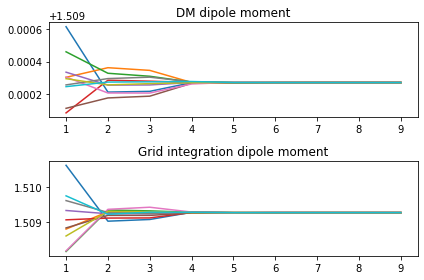

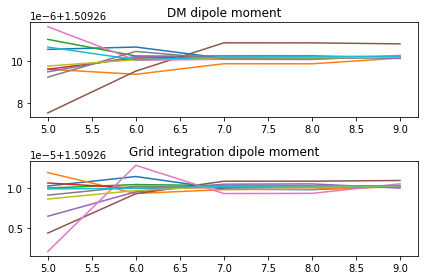

In [16]:
import matplotlib.pyplot as plt

dpm = []
grid_dpm = []
for i in range(len(results)):
    mol_res = results[i]
    dpm.append(mol_res['dpm'])
    grid_dpm.append(mol_res['grid_dpm'])

dpm = np.array(dpm, dtype=np.float64)
grid_dpm = np.array(grid_dpm, dtype=np.float64)

dpm_magnitude = np.sqrt(np.sum(dpm**2, -1))
grid_dpm_magnitude = np.sqrt(np.sum(grid_dpm**2, -1))

fig, axs = plt.subplots(2, 1)
axs[0].plot(np.arange(dpm_magnitude.shape[1]) + 1, dpm_magnitude.T)
axs[0].set_title('DM dipole moment')
axs[1].plot(np.arange(dpm_magnitude.shape[1]) + 1, grid_dpm_magnitude.T)
axs[1].set_title('Grid integration dipole moment')
fig.tight_layout()
plt.savefig('figures/dipople_moment_convergence.pdf')
plt.show()

fig, axs = plt.subplots(2, 1)
axs[0].plot(np.arange(5) + 5, dpm_magnitude.T[4:])
axs[0].set_title('DM dipole moment')
axs[1].plot(np.arange(5) + 5, grid_dpm_magnitude.T[4:])
axs[1].set_title('Grid integration dipole moment')
fig.tight_layout()
plt.savefig('figures/dipople_moment_convergence_zoomed.pdf')
plt.show()

In [192]:

for res in results:
    calc_dict = res[1]
    #print('dipole moment', calc_dict['dpm'])
    print('dipole moment magnitude', np.sqrt(np.sum(calc_dict['dpm']**2)))
    #print('grid dpm', calc_dict['grid_dpm'])
    print('grid dpm magnitude',  np.sqrt(np.sum(calc_dict['grid_dpm']**2)))
    #print('magnitude factor', np.sqrt(np.sum(calc_dict['dpm']**2)) / np.sqrt(np.sum(calc_dict['grid_dpm']**2)))
    print('dpm error', np.mean(np.sqrt(np.sum((calc_dict['grid_dpm'] - calc_dict['dpm'])**2))))

dipole moment magnitude 1.443511314973826
grid dpm magnitude 1.4433983144726752
dpm error 0.0002348211507342075
dipole moment magnitude 1.44357071873551
grid dpm magnitude 1.4434907977112195
dpm error 0.00013238068997026699
dipole moment magnitude 1.4435677089074157
grid dpm magnitude 1.4435590368804443
dpm error 8.706779879067712e-05
dipole moment magnitude 1.4435481724840276
grid dpm magnitude 1.4434398030299562
dpm error 0.00013493593664440606
dipole moment magnitude 1.443534387019964
grid dpm magnitude 1.443532324001203
dpm error 4.584469431386897e-05
dipole moment magnitude 1.4434756658409404
grid dpm magnitude 1.443472080927953
dpm error 2.6986232369583755e-05
dipole moment magnitude 1.4435340157780063
grid dpm magnitude 1.4437151595976851
dpm error 0.00023043852608598745
dipole moment magnitude 1.443543261939124
grid dpm magnitude 1.44350305618249
dpm error 0.0001337544944913597
dipole moment magnitude 1.4435355034967812
grid dpm magnitude 1.4435605254183672
dpm error 3.81558401

In [123]:
from equiv_dens.utils import grids
from pyscf.lib import param

grid_spec = grids.spherical_grid(data, level=2)
for key in grid_spec.keys():
    grid_spec[key] = (grid_spec[key][0] / param.BOHR, grid_spec[key][1])  # convert Bohr grid to Angstrom

integral_errors = []
for i, res in enumerate(results):
    mol_dict = res[0]
    mol = gto.M(atom=mol_dict['atom'], basis=mol_dict['basis'])
    calc_dict = res[1]

    #sample_coords, coord_weights = grids.spherical_sampling(grid_spec, 10000000,
    #                                            data['atom_types'],
    #                                            data['positions'][i][None, :] / param.BOHR)
    sample_coords, coord_weights = gen_grid.get_partition(mol, grid_spec,
                                   radii_adjust=None, atomic_radii=radi.BRAGG_RADII,
                                   becke_scheme=gen_grid.original_becke)
    sample_coords = sample_coords.squeeze()
    coord_weights = coord_weights.squeeze()
    print('sample_coords shape', sample_coords.shape)
    ao = numint.eval_ao(mol, sample_coords)
                # print('ao time', time.time() - ao_start)
                # rho_start = time.time()
    rho = numint.eval_rho2(mol, ao, mo_coeff=calc_dict['mo_coeff'], mo_occ=calc_dict['mo_occ'])
    max_rho = np.argmax(rho)
    print('density integral:', np.sum(rho * coord_weights))
    print('density shape', rho.shape)
    integral_errors.append(np.abs(np.sum(rho * coord_weights) - np.sum(mol.atom_charges())))
    print('max rho idx', max_rho)
    print('max rho coords', mf.grids.coords[max_rho, :])
    print('positions', data['positions'][i])
    print('atom coords', mol.atom_coords())
    print('grid coords', sample_coords)
    print('grid weights', coord_weights)
    print('rho', rho)
    grid_e_dpm = np.sum((rho * coord_weights)[:, None] * sample_coords, axis=0)
    grid_nuc_dpm = np.sum(mol.atom_coords() * mol.atom_charges()[:, None], axis=0)
    grid_dpm = grid_nuc_dpm - grid_e_dpm
    grid_dpm *= nist.AU2DEBYE
    print('dipole moment', grid_dpm)
    
print('mean integration error', np.mean(integral_errors))

level 2
sample_coords shape (100920, 3)
density integral: 25.999974270623696
density shape (100920,)
max rho idx 37032
max rho coords [ 1.81681203  0.00602359 -1.411546  ]
positions [[-0.19233131 -0.42112186 -0.27799532]
 [ 1.23673728  0.14677226 -0.46928095]
 [-0.97713625  0.19850429  0.6986113 ]
 [-0.66821324 -0.41067343 -1.28560746]
 [-0.02164145 -1.54970684 -0.01778779]
 [ 1.57094402 -0.0362462  -1.47564077]
 [ 1.23677893  1.22823969 -0.2575283 ]
 [ 1.89078874 -0.29183454  0.27473129]
 [-0.94386202  1.177076    0.57606495]]
atom coords [[-0.3634535  -0.79580498 -0.52533502]
 [ 2.33709475  0.27735937 -0.88681247]
 [-1.8465199   0.37511874  1.32018402]
 [-1.26274002 -0.77606031 -2.429446  ]
 [-0.04089641 -2.9285215  -0.03361405]
 [ 2.96865395 -0.06849539 -2.78855691]
 [ 2.33717345  2.32103663 -0.48665796]
 [ 3.57307288 -0.55148735  0.5191669 ]
 [-1.78364072  2.22435127  1.08860499]]
grid coords [[-0.36343554 -0.79580498 -0.52533502]
 [-0.36328847 -0.79580498 -0.52533502]
 [-0.3628495

sample_coords shape (100920, 3)
density integral: 25.999934472822197
density shape (100920,)
max rho idx 36420
max rho coords [ 1.81679723  0.00602141 -1.41151707]
positions [[-0.22195051 -0.49134457 -0.03057504]
 [-0.96902871  0.74978069  0.51970962]
 [ 1.07965972 -0.27422235 -0.49131858]
 [-0.27371466 -1.26517284  0.76965324]
 [-0.9080798  -0.88083687 -0.89548508]
 [-1.70619883  0.44247568  1.24088492]
 [-0.24681809  1.44145685  0.98275057]
 [-1.3991282   1.29678769 -0.3106585 ]
 [ 1.58697326  0.2370453   0.18319288]]
atom coords [[-0.41942568 -0.92850667 -0.05777845]
 [-1.83119887  1.41688016  0.98210885]
 [ 2.04026118 -0.51820514 -0.92845756]
 [-0.51724574 -2.39083017  1.45443383]
 [-1.71602212 -1.66454044 -1.69222155]
 [-3.2242485   0.83615785  2.34493265]
 [-0.46641859  2.72395867  1.85712943]
 [-2.64396911  2.45057358 -0.58705948]
 [ 2.99894483  0.4479507   0.34618437]]
grid coords [[ -0.41940772  -0.92850667  -0.05777845]
 [ -0.41926064  -0.92850667  -0.05777845]
 [ -0.4188217 

In [183]:
from equiv_dens.utils import grids
from equiv_dens.utils import base as utils
import torch


def stratmann(g):
    '''Stratmann, Scuseria, Frisch. CPL, 257, 213 (1996); DOI:10.1016/0009-2614(96)00600-8'''
    a = .64  # for eq. 14
    g = np.asarray(g)
    ma = g/a
    ma2 = ma * ma
    g1 = np.asarray((1/16.)*(ma*(35 + ma2*(-35 + ma2*(21 - 5 *ma2)))))
    g1[g<=-a] = -1
    g1[g>= a] =  1
    return g1


def recreated_becke(g):
    '''Becke, JCP 88, 2547 (1988); DOI:10.1063/1.454033'''
#    This funciton has been optimized in the C code VXCgen_grid
    g = (3 - g**2) * g * .5
    g = (3 - g**2) * g * .5
    g = (3 - g**2) * g * .5
    
    return g


def gen_grid_partition(positions, atom_types, coords, becke_scheme, f_radii_adjust=None):
            ngrids = coords.shape[1]
            natm = positions.shape[1]
            nbatch = positions.shape[0]
            atm_dist, _ = utils.calculate_distances_and_directions(torch.tensor(positions))
            atm_dist = atm_dist.numpy()
            #print('atm dist shape', atm_dist.shape)
            dc = coords[:, None] - positions[:, :, None]
            #print('dc shape', dc.shape)
            grid_dist = np.sqrt(np.einsum('pqij,pqij->pqi',dc,dc))
            pbecke = np.ones((nbatch, natm, ngrids))
            for i in range(natm):
                for j in range(i):
                    g = 1/atm_dist[:, i, j] * (grid_dist[:, i]-grid_dist[:, j])
                    if f_radii_adjust is not None:
                        g = f_radii_adjust(i, j, g)
                    g = becke_scheme(g)
                    #print('g shape', g.shape)
                    pbecke[:,i] *= .5 * (1-g)
                    pbecke[:,j] *= .5 * (1+g)
            return pbecke
        
def gen_grid_partition(positions, atom_types, coords, becke_scheme, f_radii_adjust=None):
            ngrids = coords.shape[1]
            natm = positions.shape[1]
            nbatch = positions.shape[0]
            atm_dist, _ = utils.calculate_distances_and_directions(torch.tensor(positions))
            atm_dist = atm_dist.numpy()
            #print('atm dist shape', atm_dist.shape)
            dc = coords[:, None] - positions[:, :, None]
            #print('dc shape', dc.shape)
            grid_dist = np.sqrt(np.sum(dc**2, axis=-1))
            pbecke = np.ones((nbatch, natm, ngrids))
            for i in range(natm):
                for j in range(i):
                    g = 1/atm_dist[:, i, j] * (grid_dist[:, i]-grid_dist[:, j])
                    if f_radii_adjust is not None:
                        g = f_radii_adjust(i, j, g)
                    g = becke_scheme(g)
                    #print('g shape', g.shape)
                    pbecke[:,i] *= .5 * (1-g)
                    pbecke[:,j] *= .5 * (1+g)
            return pbecke        
        
def spherical_sampling_rescale(grid_spec, n_samp, atom_types, pos, radii_adjust=None):
    grid_coords = []
    grid_weights = []
    #for key in grid_spec.keys():
        #print(key, ':', grid_spec[key][0].shape)
    for i, t in enumerate(atom_types):
        coords = pos[:, [i], :] + (grid_spec[t][0][None, :])
        weights = grid_spec[t][1]
        #grid_coords.append(pos[:, [i], :] + (grid_spec[t][0][None, :]))
        #grid_weights.append(grid_spec[t][1] / len(atom_types))
        pbecke = gen_grid_partition_torch(pos, atom_types, coords, recreated_becke, radii_adjust)
        weights = weights * pbecke[:, i] * (1./pbecke.sum(1))
        grid_coords.append(coords)
        grid_weights.append(weights)
    
    return grids.collect_and_sample_grid(grid_coords, grid_weights, n_samp)


def treutler_atomic_radii_adjust(charges, atomic_radii):
    rad = np.sqrt(atomic_radii[charges]) + 1e-200
    rr = rad.reshape(-1,1) * (1./rad)
    a = .25 * (rr.T - rr)
    a[a<-.5] = -.5
    a[a>0.5] = 0.5
    #:return lambda i,j,g: g + a[i,j]*(1-g**2)
    def fadjust(i, j, g):
        g1 = g**2
        g1 -= 1.
        g1 *= -a[i,j]
        g1 += g
        return g1
    return fadjust

def gen_grid_partition_torch(positions, atom_types, coords, becke_scheme, f_radii_adjust=None):
            ngrids = coords.shape[1]
            natm = positions.shape[1]
            nbatch = positions.shape[0]
            atm_dist, _ = utils.calculate_distances_and_directions(positions)
            #print('atm dist shape', atm_dist.shape)
            dc = coords[:, None] - positions[:, :, None]
            #print('dc shape', dc.shape)
            grid_dist = torch.sqrt(torch.sum(dc**2, dim=-1))
            pbecke = torch.ones((nbatch, natm, ngrids)).to(positions)
            for i in range(natm):
                for j in range(i):
                    g = 1/atm_dist[:, i, j] * (grid_dist[:, i]-grid_dist[:, j])
                    if f_radii_adjust is not None:
                        g = f_radii_adjust(i, j, g)
                    g = becke_scheme(g)
                    #print('g shape', g.shape)
                    pbecke[:,i] *= .5 * (1-g)
                    pbecke[:,j] *= .5 * (1+g)
            return pbecke        
        
def treutler_atomic_radii_adjust_torch(charges, atomic_radii):
    rad = torch.sqrt(atomic_radii[charges]) + 1e-200
    rr = rad.reshape(-1,1) * (1./rad)
    a = .25 * (rr.T - rr)
    a[a<-.5] = -.5
    a[a>0.5] = 0.5
    #:return lambda i,j,g: g + a[i,j]*(1-g**2)
    def fadjust(i, j, g):
        g1 = g**2
        g1 -= 1.
        g1 *= -a[i,j]
        g1 += g
        return g1
    return fadjust


In [187]:
import time

grid_spec = grids.spherical_grid(data, level=1)
for key in grid_spec.keys():
    grid_spec[key] = (grid_spec[key][0] / param.BOHR, grid_spec[key][1])  # convert Angstrom grid to Bohr

integral_errors = []
start = time.time()
sample_coords = []
coord_weights = []
#for i, res in enumerate(results):
#    mol_dict = res[0]
#    mol = gto.M(atom=mol_dict['atom'], basis=mol_dict['basis'])
#    calc_dict = res[1]
#    sample_coords_i, coord_weights_i = gen_grid.get_partition(mol, grid_spec,
#                                   radii_adjust=radi.treutler_atomic_radii_adjust,
#                                   atomic_radii=radi.BRAGG_RADII,
#                                   becke_scheme=gen_grid.original_becke)
#    sample_coords.append(sample_coords_i)
#    coord_weights.append(coord_weights_i)
#sample_coords = np.stack(sample_coords, 0)
#coord_weights = np.stack(coord_weights, 0)
#print(sample_coords.shape)
#print(coord_weights.shape)


for key in grid_spec.keys():
    grid_spec[key] = (torch.tensor(grid_spec[key][0]).cuda(), torch.tensor(grid_spec[key][1]).cuda())
f_radii_adjust = treutler_atomic_radii_adjust_torch(utils.symbols_to_numbers(data['atom_types']), torch.tensor(radi.BRAGG_RADII).cuda())
sample_coords, coord_weights = spherical_sampling_rescale(grid_spec, 10000000,
                                                        data['atom_types'],
                                                        torch.tensor(data['positions']).cuda() / param.BOHR,
                                                        radii_adjust=f_radii_adjust)
#coord_weights = coord_weights[None, :].repeat(10, axis=0)
#pbecke = gen_grid_partition(data['positions'] / param.BOHR, data['atom_types'], sample_coords, stratmann, None)
#pbecke = pbecke.reshape(pbecke.shape[0], -1)
#coord_weights = coord_weights * len(data['atom_types']) * pbecke * (1./pbecke.sum(axis=1))
print('sample_coords type', type(sample_coords))
print('sample_coords shape', sample_coords.shape)

print('grid sampling time', time.time() - start)
integral_errors = []
for i, res in enumerate(results):
    #print('sample_coords', sample_coords[i])
    mol_dict = res[0]
    mol = gto.M(atom=mol_dict['atom'], basis=mol_dict['basis'])
    #print('mol coords', mol.atom_coords())
    calc_dict = res[1]
    ao = numint.eval_ao(mol, sample_coords[i].detach().cpu().numpy())
    rho = numint.eval_rho2(mol, ao, mo_coeff=calc_dict['mo_coeff'], mo_occ=calc_dict['mo_occ'])
#    #numpy version
#    print('density integral:', np.sum(rho * coord_weights[i]))
#    integral_errors.append(np.abs(np.sum(rho * coord_weights[i]) - np.sum(mol.atom_charges())))
    #torch version
    rho = torch.tensor(rho).to(sample_coords)
    charges = torch.tensor(mol.atom_charges())
    print('density integral:', torch.sum(rho * coord_weights[i]))
    integral_errors.append(torch.abs(torch.sum(rho * coord_weights[i]) - torch.sum(charges)))
#grid sampling timing
print('mean integration error', sum(integral_errors)/len(integral_errors))

level 1


/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/ipykernel_launcher.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).


sample_coords type <class 'torch.Tensor'>
sample_coords shape torch.Size([10, 43080, 3])
grid sampling time 0.2516462802886963
density integral: tensor(25.9999, device='cuda:0', dtype=torch.float64)
density integral: tensor(26.0000, device='cuda:0', dtype=torch.float64)
density integral: tensor(26.0002, device='cuda:0', dtype=torch.float64)
density integral: tensor(26.0002, device='cuda:0', dtype=torch.float64)
density integral: tensor(26.0000, device='cuda:0', dtype=torch.float64)
density integral: tensor(25.9999, device='cuda:0', dtype=torch.float64)
density integral: tensor(26.0002, device='cuda:0', dtype=torch.float64)
density integral: tensor(26.0000, device='cuda:0', dtype=torch.float64)
density integral: tensor(26.0001, device='cuda:0', dtype=torch.float64)
density integral: tensor(25.9998, device='cuda:0', dtype=torch.float64)
mean integration error tensor(0.0001, device='cuda:0', dtype=torch.float64)
